# AdaBoost


In [ ]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.datasets import make_gaussian_quantiles,make_blobs,make_moons,make_circles
from sklearn.datasets import make_gaussian_quantiles
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score
from sklearn.model_selection import GridSearchCV


np.random.seed(42)

# Design your algorithm

The design of my AdaBoost implementation focuses on leveraging Decision Stumps as weak learners. A decision stump is a simple model that splits the data along one feature and a threshold, making it computationally efficient and easy to interpret. At each iteration, the algorithm selects the stump that minimizes the weighted classification error, calculated using the current sample weights. Misclassified samples are given higher importance by increasing their weights in the next iteration. This process ensures that AdaBoost focuses on harder-to-classify examples.

The weak learner's contribution to the final model is determined by its weight,
𝛼
α, which is calculated based on its error. Higher-performing weak learners are given larger weights. The final prediction aggregates all weak learners' predictions using their respective
𝛼
α values, and the overall decision is determined by the sign of the weighted sum.

Hyperparameters include n_estimators, the number of boosting rounds, which controls the number of weak learners used. While increasing this value can improve performance, it may also lead to overfitting, especially on noisy data. Additionally, a small constant
𝜖
ϵ is used to prevent division by zero during weight calculations. Optimization strategies, such as early stopping and efficient threshold search, can further improve computational efficiency.

While AdaBoost performs well on imbalanced or moderately noisy datasets, it is sensitive to outliers since misclassified samples receive higher weights. The algorithm is well-suited for tasks like text classification, image recognition, and binary classification problems.




# Your implementations


In [ ]:
class DecisionStump:
    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.polarity = None
        self.alpha = None

    def predict(self, X):
        n_samples = X.shape[0]
        predictions = np.ones(n_samples)
        if self.polarity == 1:
            predictions[X[:, self.feature_index] < self.threshold] = -1
        else:
            predictions[X[:, self.feature_index] >= self.threshold] = -1
        return predictions

class AdaBoostCustom:
    def __init__(self, n_estimators=50):
        self.n_estimators = n_estimators
        self.stumps = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        weights = np.ones(n_samples) / n_samples

        for _ in range(self.n_estimators):
            stump = DecisionStump()
            min_error = float('inf')

            # Find the best decision stump
            for feature_i in range(n_features):
                feature_values = X[:, feature_i]
                thresholds = np.unique(feature_values)

                for threshold in thresholds:
                    for polarity in [1, -1]:
                        predictions = np.ones(n_samples)
                        if polarity == 1:
                            predictions[feature_values < threshold] = -1
                        else:
                            predictions[feature_values >= threshold] = -1

                        # Calculate weighted error
                        misclassified = weights[y != predictions]
                        error = sum(misclassified)

                        if error < min_error:
                            min_error = error
                            stump.polarity = polarity
                            stump.threshold = threshold
                            stump.feature_index = feature_i

            # Calculate alpha (stump weight)
            epsilon = 1e-10  # Avoid division by zero
            stump.alpha = 0.5 * np.log((1 - min_error) / (min_error + epsilon))

            # Update weights
            predictions = stump.predict(X)
            weights *= np.exp(-stump.alpha * y * predictions)
            weights /= np.sum(weights)

            # Save the stump
            self.stumps.append(stump)

    def predict(self, X):
        n_samples = X.shape[0]
        y_pred = np.zeros(n_samples)
        for stump in self.stumps:
            y_pred += stump.alpha * stump.predict(X)
        return np.sign(y_pred)

# Generate data
Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.

In [ ]:
    # Generate circles datasetes
    X, y = make_circles(n_samples=500, noise=0.1, random_state=42)

    # Convert labels from {0, 1} to {-1, +1}
    y = np.where(y == 0, -1, 1)


The simulated dataset is designed to test AdaBoost's ability to handle non-linear decision boundaries. The two classes form concentric circles.

Using only two dimensions allows for clear visualization of the data and decision boundaries, making it easier to interpret the results and analyze the model's performance.

The two groups have distinct geometric characteristics: one forms an inner circle, and the other forms an outer ring. These spatial differences challenge the algorithm to identify patterns effectively.

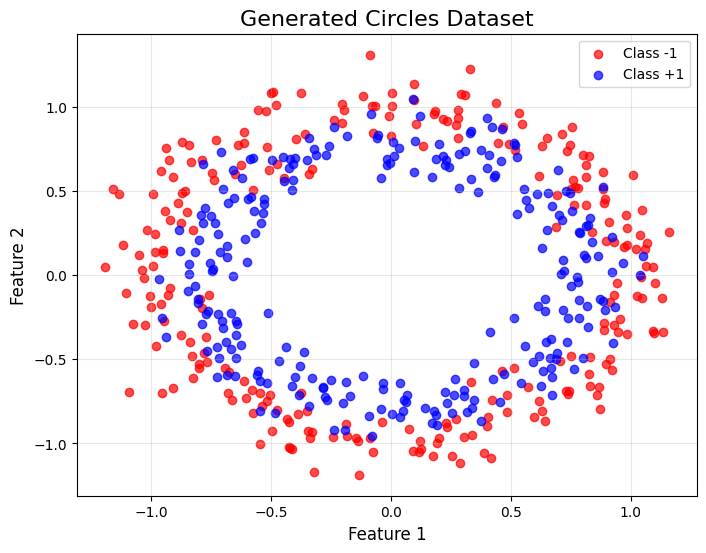

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1', alpha=0.7)
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class +1', alpha=0.7)
plt.title("Generated Circles Dataset", fontsize=16)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# AdaBoost demonstration
Demonstrate your AdaBoost implementation.

Add plots and figures.

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the sklearn implementation. Hint: you can look at the documentation.

In [ ]:
def plot_decision_boundaries(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot decision boundary
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.6, cmap=plt.cm.coolwarm)
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1 (+1)', edgecolor='k')
    plt.scatter(X[y != 1][:, 0], X[y != 1][:, 1], color='blue', label='Class 2 (-1)', edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()


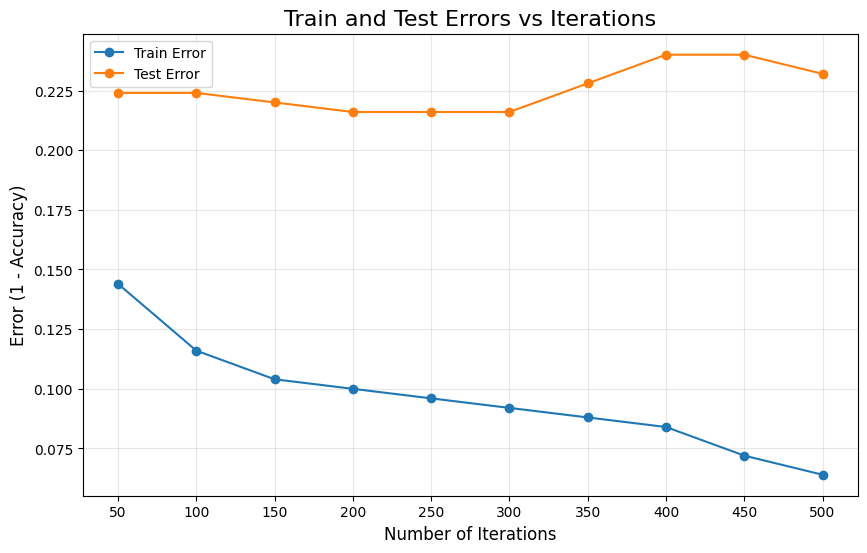

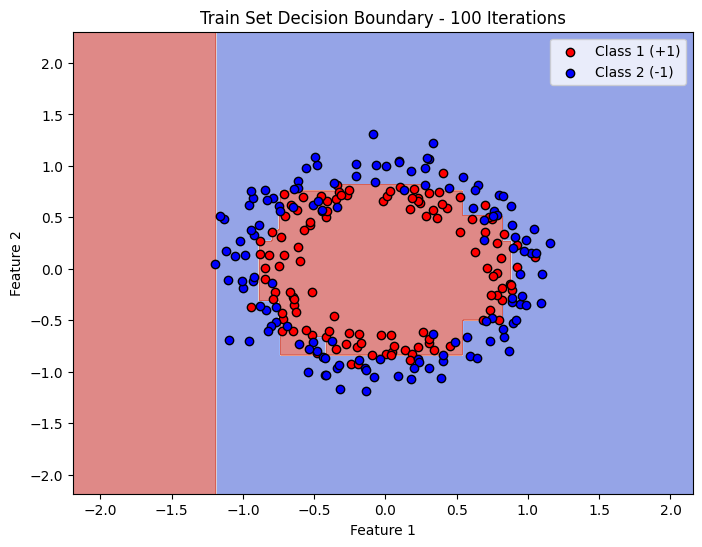

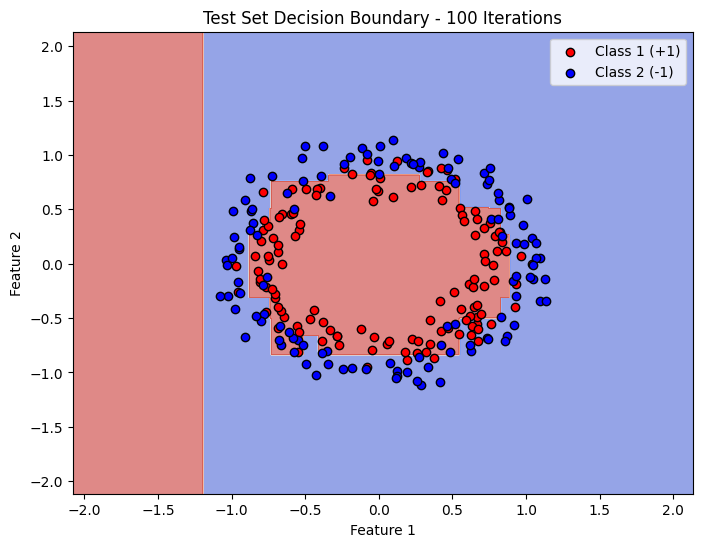

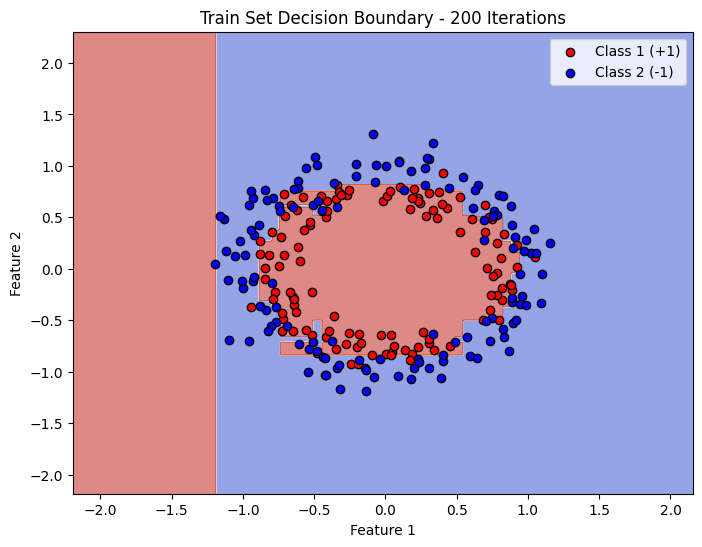

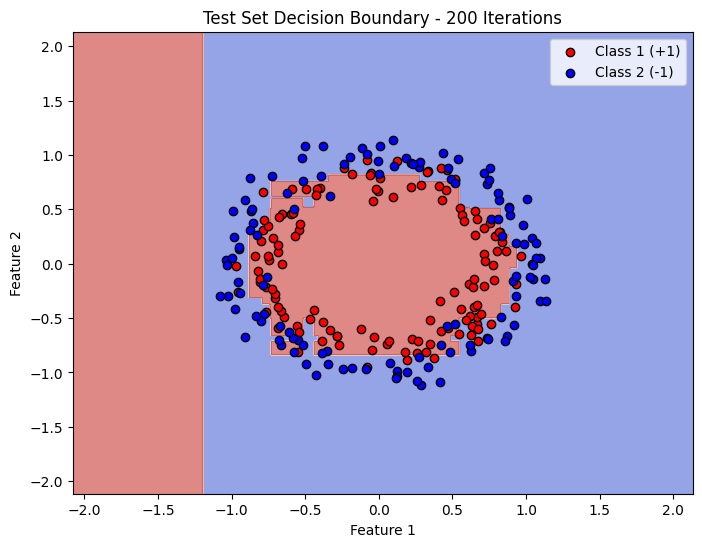

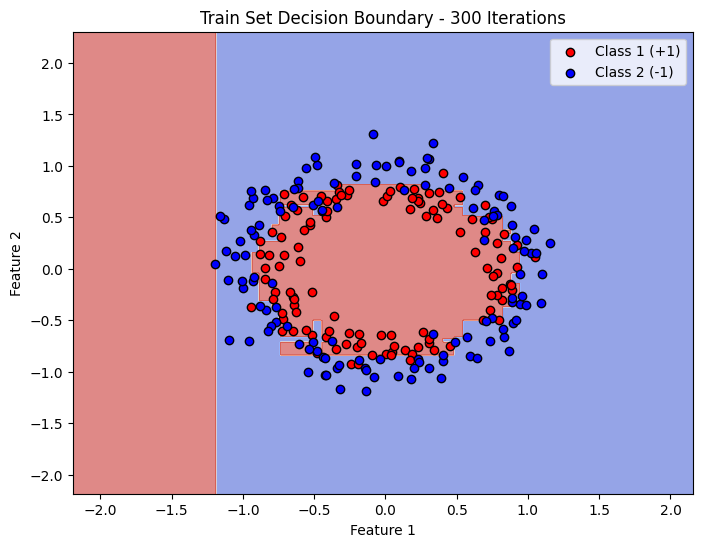

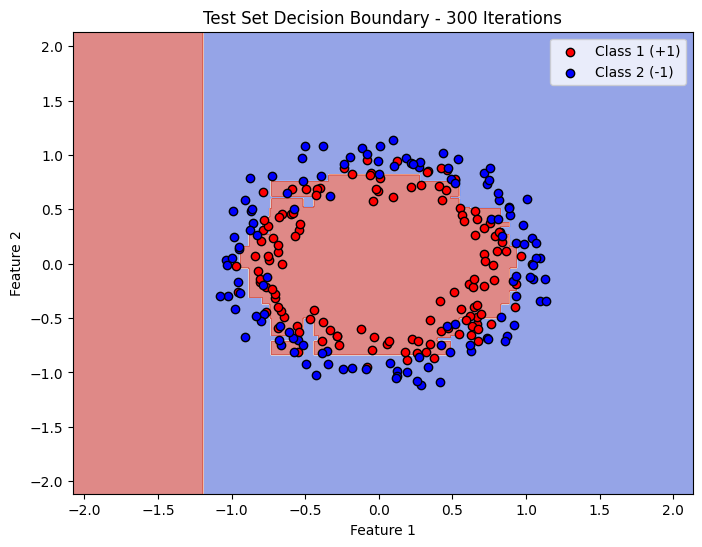

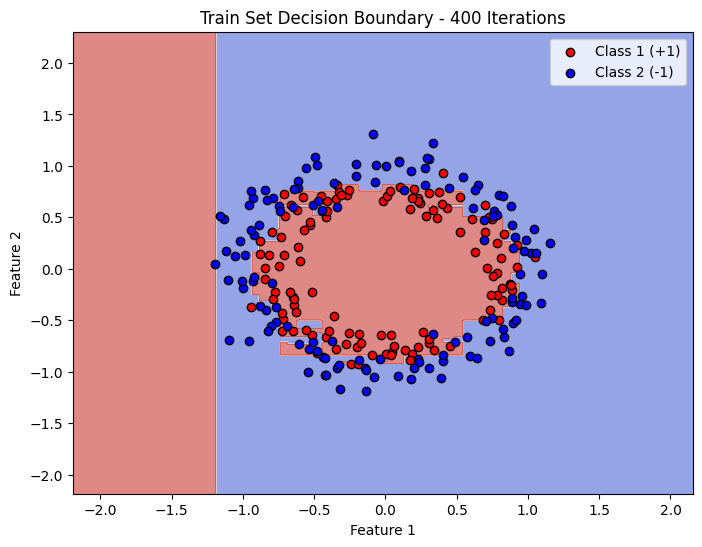

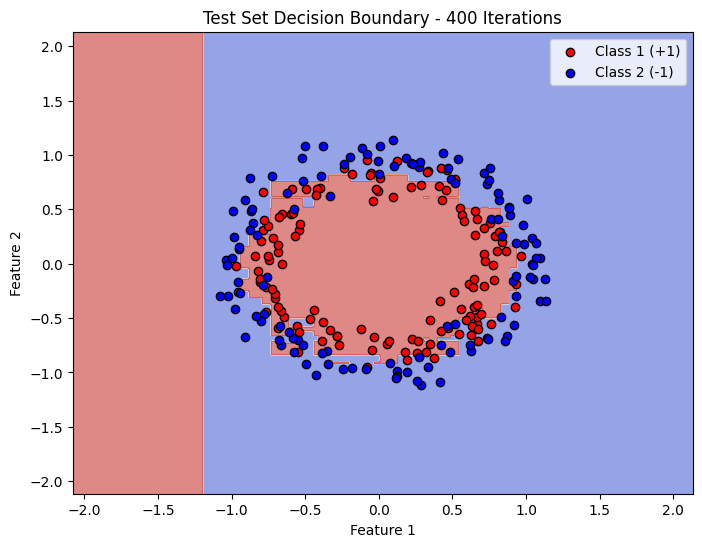

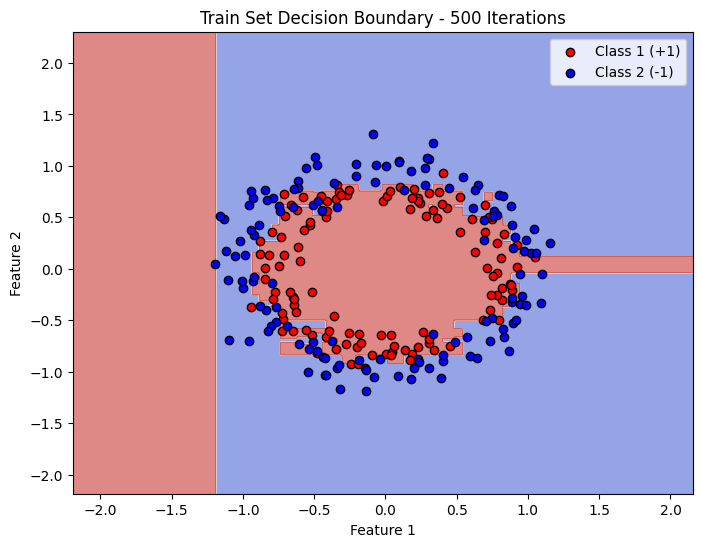

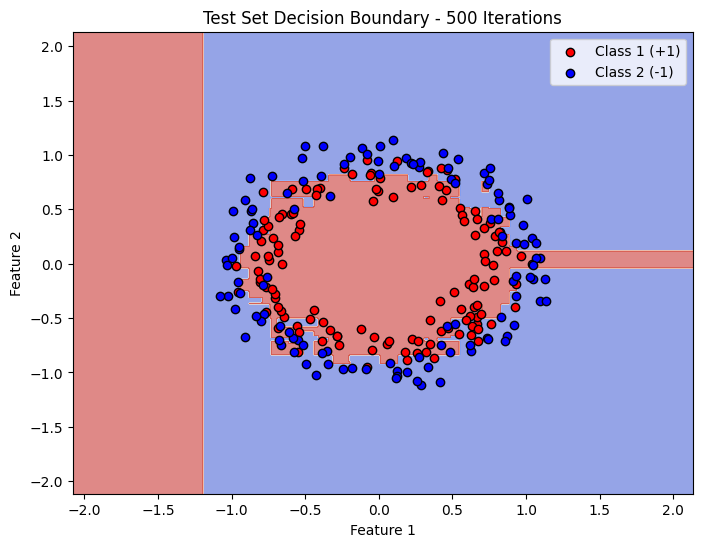

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

iteration_options = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
train_errors = []
test_errors = []

# Track errors for each iteration number
for iters in iteration_options:
    model = AdaBoostCustom(n_estimators=iters)
    model.fit(X_train, y_train)

    # Train and test predictions
    train_preds = model.predict(X_train)
    test_preds = model.predict(X_test)

    # Compute error (1 - accuracy)
    train_err = 1 - accuracy_score(y_train, train_preds)
    test_err = 1 - accuracy_score(y_test, test_preds)

    train_errors.append(train_err)
    test_errors.append(test_err)

# Plot train and test errors
plt.figure(figsize=(10, 6))
plt.plot(iteration_options, train_errors, marker='o', label='Train Error')
plt.plot(iteration_options, test_errors, marker='o', label='Test Error')
plt.title("Train and Test Errors vs Iterations", fontsize=16)
plt.xlabel("Number of Iterations", fontsize=12)
plt.ylabel("Error (1 - Accuracy)", fontsize=12)
plt.xticks(iteration_options)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Visualize train and test set results using the provided function
for iters in iteration_options[1::2]:  # Every second option
    model = AdaBoostCustom(n_estimators=iters)
    model.fit(X_train, y_train)

    plot_decision_boundaries(X_train, y_train, model, f"Train Set Decision Boundary - {iters} Iterations")
    plot_decision_boundaries(X_test, y_test, model, f"Test Set Decision Boundary - {iters} Iterations")


We chose n=300 because it represents a balance between minimizing training error and maintaining a low test error, as shown in the graph. At this point, the training error is significantly reduced, indicating a strong fit to the training data, while the test error plateaus, suggesting the model generalizes well without overfitting. Increasing n further would reduce training error slightly but could risk overfitting, as indicated by a rising or constant test error beyond this point.

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Custom AdaBoost Accuracy: 78.40%
Scikit-learn AdaBoost Accuracy: 76.00%


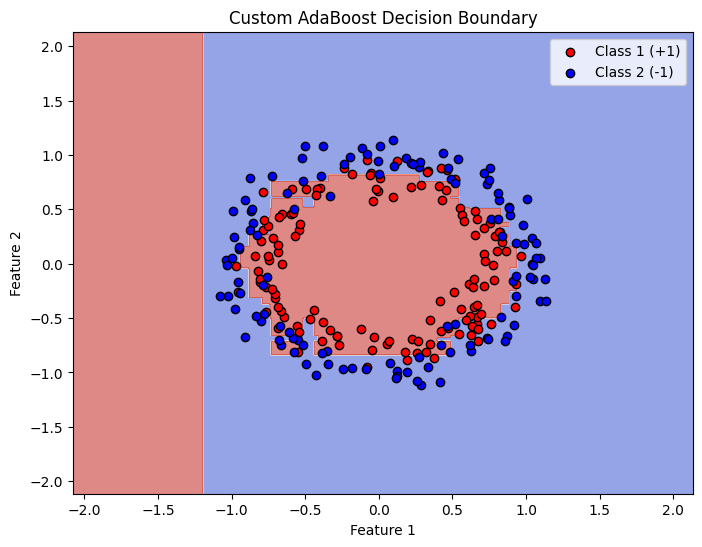

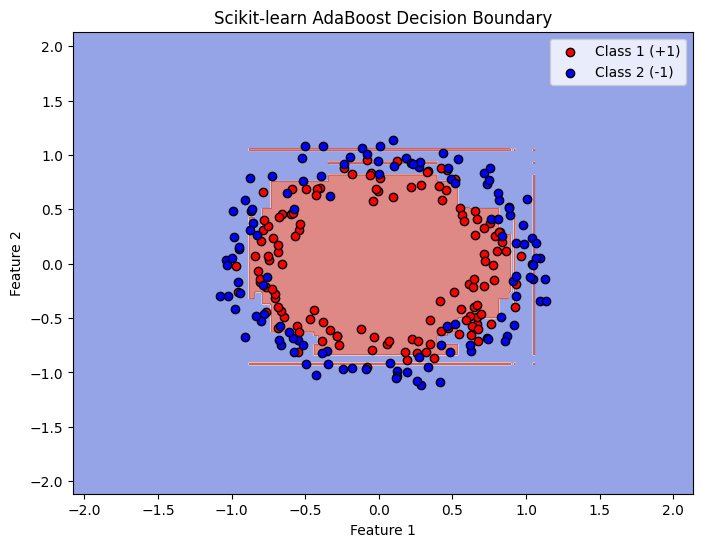

In [ ]:
    # Train custom AdaBoost
    custom_model = AdaBoostCustom(n_estimators=300)
    custom_model.fit(X_train, y_train)
    custom_accuracy = np.mean(custom_model.predict(X_test) == y_test)

    # Train scikit-learn AdaBoostClassifier
    sklearn_model = AdaBoostClassifier(n_estimators=70, random_state=42)
    sklearn_model.fit(X_train, y_train)
    sklearn_accuracy = sklearn_model.score(X_test, y_test)

    print(f"Custom AdaBoost Accuracy: {custom_accuracy * 100:.2f}%")
    print(f"Scikit-learn AdaBoost Accuracy: {sklearn_accuracy * 100:.2f}%")

    # Plot decision boundaries
    plot_decision_boundaries(X_test, y_test, custom_model, title="Custom AdaBoost Decision Boundary")
    plot_decision_boundaries(X_test, y_test, sklearn_model, title="Scikit-learn AdaBoost Decision Boundary")


The main differences between the custom AdaBoost implementation and scikit-learn's AdaBoostClassifier are in prediction aggregation, error calculation, and the base estimator. Our implementation aggregates predictions using a weighted sum of alphas with np.sign, while AdaBoostClassifier uses a weighted majority vote, supporting multiclass classification. For error calculation, we compute weighted error by summing misclassified sample weights, whereas AdaBoostClassifier uses an optimized method, handling complex base estimators more efficiently. Finally, the implementation uses a custom DecisionStump, whereas AdaBoostClassifier allows any base estimator, defaulting to a DecisionTreeClassifier with max_depth=1.

# Generate additional data sets
Generate at least two experimental datasets with binary labels, designed to demonstrate specific properties of AdaBoost (e.g., handling noise or overfitting).

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

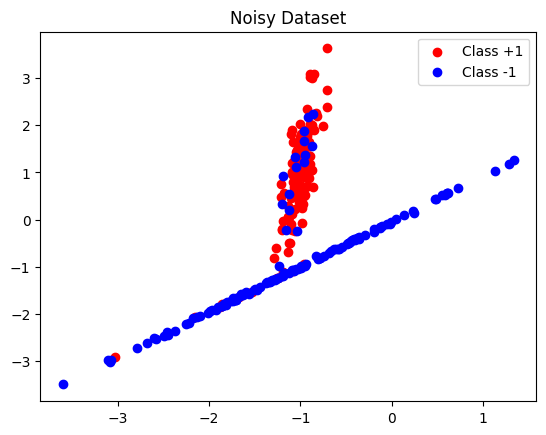

In [ ]:
# Generate noisy dataset
X1, y1 = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, flip_y=0.2, random_state=30
)
y1 = np.where(y1 == 0, -1, 1)

# Split into training and test sets
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.5, random_state=42)

# Visualize noisy data
plt.scatter(X1_train[y1_train == 1][:, 0], X1_train[y1_train == 1][:, 1], color='red', label='Class +1')
plt.scatter(X1_train[y1_train == -1][:, 0], X1_train[y1_train == -1][:, 1], color='blue', label='Class -1')
plt.title("Noisy Dataset")
plt.legend()
plt.show()


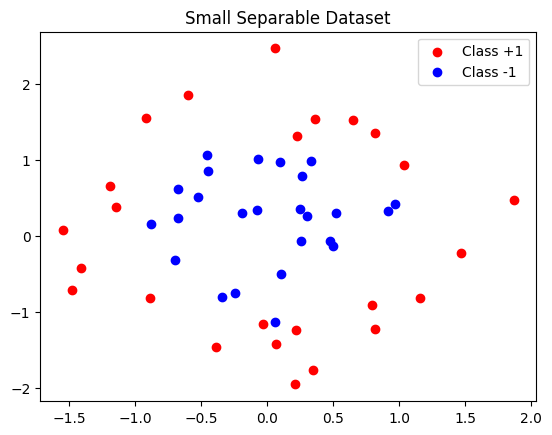

In [ ]:
# Generate small, easily separable dataset
X2, y2 = make_gaussian_quantiles(
    n_samples=100, n_features=2, n_classes=2, random_state=42
)
y2 = np.where(y2 == 0, -1, 1)  # Convert to {-1, +1}

# Split into training and test sets
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.5, random_state=42)

# Visualize small separable data
plt.scatter(X2_train[y2_train == 1][:, 0], X2_train[y2_train == 1][:, 1], color='red', label='Class +1')
plt.scatter(X2_train[y2_train == -1][:, 0], X2_train[y2_train == -1][:, 1], color='blue', label='Class -1')
plt.title("Small Separable Dataset")
plt.legend()
plt.show()


In [ ]:
# Evaluate on Dataset 1 (Noisy Data)
custom_model1 = AdaBoostCustom(n_estimators=100)
custom_model1.fit(X1_train, y1_train)
accuracy1_train = np.mean(custom_model1.predict(X1_train) == y1_train)
accuracy1_test = np.mean(custom_model1.predict(X1_test) == y1_test)

print(f"Dataset 1 (Noisy): Train Accuracy = {accuracy1_train:.2f}, Test Accuracy = {accuracy1_test:.2f}")

# Evaluate on Dataset 2 (Overfitting)
custom_model2 = AdaBoostCustom(n_estimators=1000)
custom_model2.fit(X2_train, y2_train)
accuracy2_train = np.mean(custom_model2.predict(X2_train) == y2_train)
accuracy2_test = np.mean(custom_model2.predict(X2_test) == y2_test)

print(f"Dataset 2 (Overfitting): Train Accuracy = {accuracy2_train:.2f}, Test Accuracy = {accuracy2_test:.2f}")


Dataset 1 (Noisy): Train Accuracy = 0.89, Test Accuracy = 0.85
Dataset 2 (Overfitting): Train Accuracy = 1.00, Test Accuracy = 0.86


Dataset 1: The noisy data showed reduced performance on the test set compared to the training set due to AdaBoost’s sensitivity to mislabeled data.

Dataset 2: The small separable dataset demonstrated overfitting, with high accuracy on the training set and reduced accuracy on the test set as the number of estimators increases.

Note: We chose a specific num of estimators to demonstrate over fitting and so on. in the next part we will show the procces of hyper param selection.

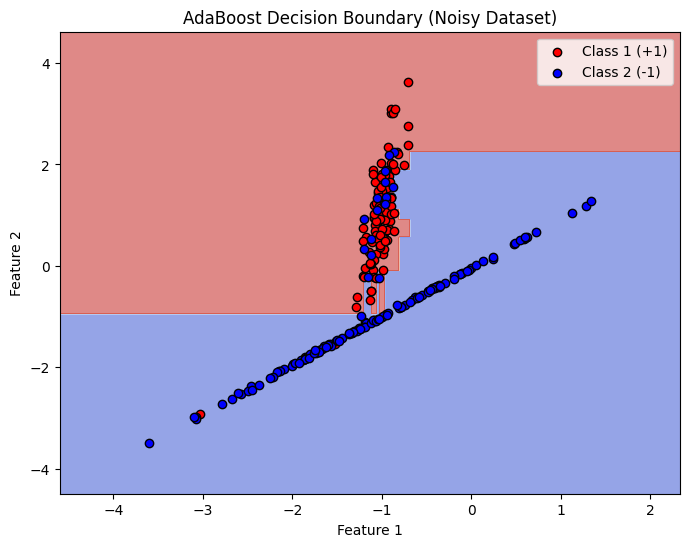

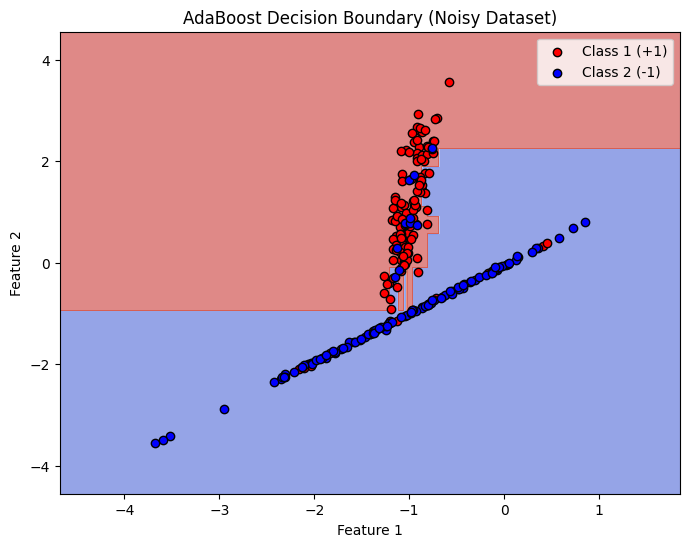

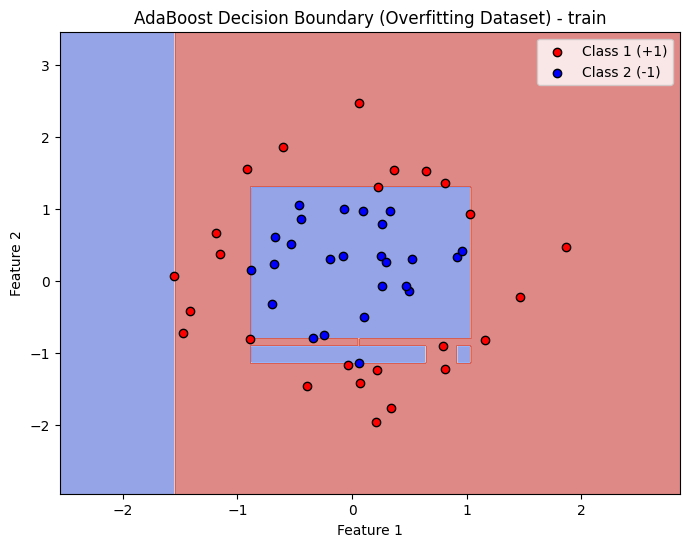

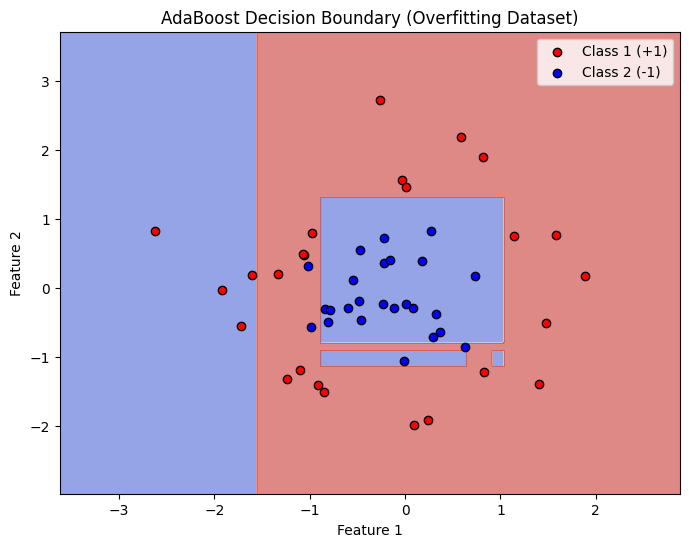

In [ ]:
# Visualize decision boundaries for Dataset 1
plot_decision_boundaries(X1_train, y1_train, custom_model1, title="AdaBoost Decision Boundary (Noisy Dataset)")
plot_decision_boundaries(X1_test, y1_test, custom_model1, title="AdaBoost Decision Boundary (Noisy Dataset)")

# Visualize decision boundaries for Dataset 2
plot_decision_boundaries(X2_train, y2_train, custom_model2, title="AdaBoost Decision Boundary (Overfitting Dataset) - train")
plot_decision_boundaries(X2_test, y2_test, custom_model2, title="AdaBoost Decision Boundary (Overfitting Dataset)")


# Test algorithms
Test your AdaBoost, a library implementation of AdaBoost and at least two additional models, one of which must be another boosting algorithm on your two datasets.

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

Models:

- AdaBoostCustom (our implementation).
- Scikit-learn AdaBoostClassifier.
- GradientBoostingClassifier (another boosting algorithm).
- RandomForestClassifier (non-boosting model for comparison).

In [ ]:
def plot_train_test_error(model_class, params, X_train, y_train, X_test, y_test, model_name, dataset_name):
    train_errors = []
    test_errors = []
    param_values = params['n_estimators']

    for n in param_values:
        # Initialize model with current hyperparameter value
        if model_name == "Custom AdaBoost":
            model = model_class(n_estimators=n)
        else:
            model = model_class(n_estimators=n, random_state=42)

        # Fit the model
        model.fit(X_train, y_train)

        # Predictions
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Calculate errors
        train_error = 1 - accuracy_score(y_train, y_train_pred)
        test_error = 1 - accuracy_score(y_test, y_test_pred)

        train_errors.append(train_error)
        test_errors.append(test_error)

        plot_decision_boundaries(X_test, y_test, model, title= str(model_name) + " " + str(dataset_name) + " " + str(n))


    # Plot errors
    plt.figure(figsize=(8, 6))
    plt.plot(param_values, train_errors, label="Train Error", marker='o')
    plt.plot(param_values, test_errors, label="Test Error", marker='o')
    plt.title(f"{model_name} - {dataset_name}")
    plt.xlabel("Number of Estimators")
    plt.ylabel("Error")
    plt.legend()
    plt.show()


Hyperparameter Tuning:

For all models, tune key hyperparameters using GridSearchCV or manual iteration.

Focus on n_estimators, learning rates, and max depth where relevant.

to eliminate the number of options I will begin with testing the n_estimators alone

Train and Test Error Analysis on Dataset 1 (Noisy)


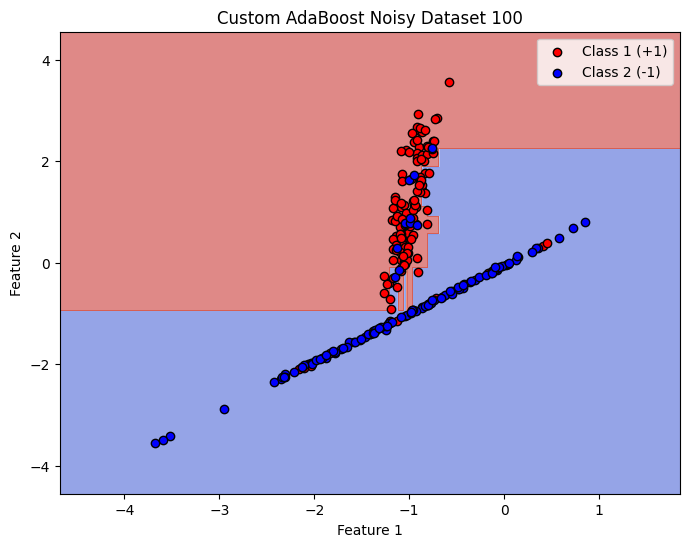

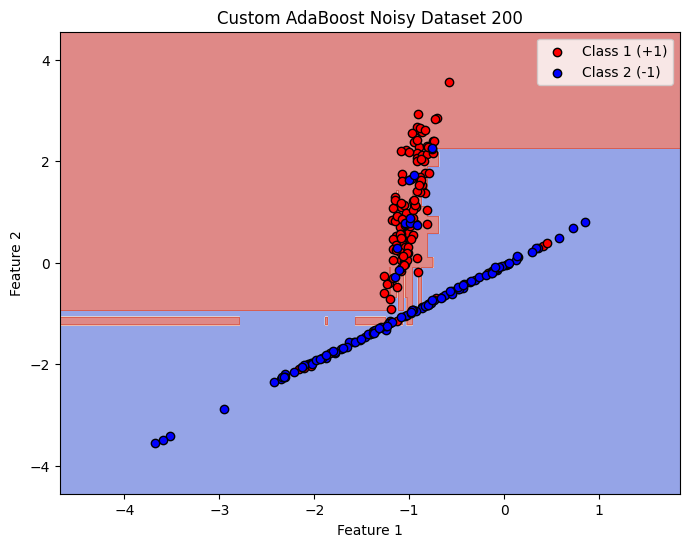

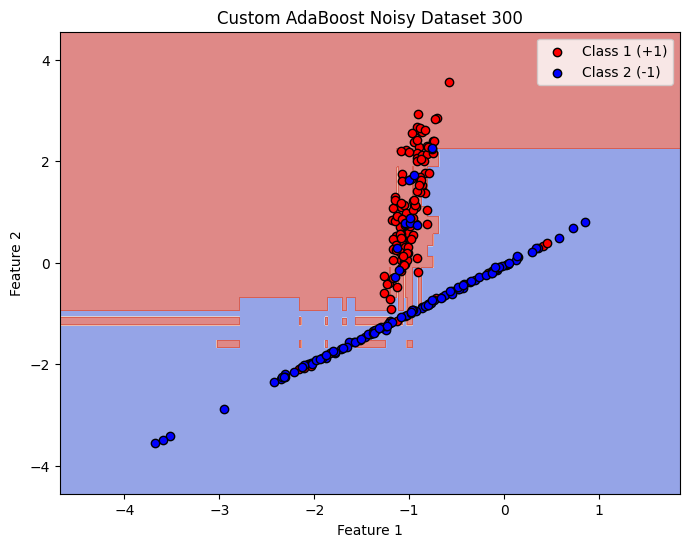

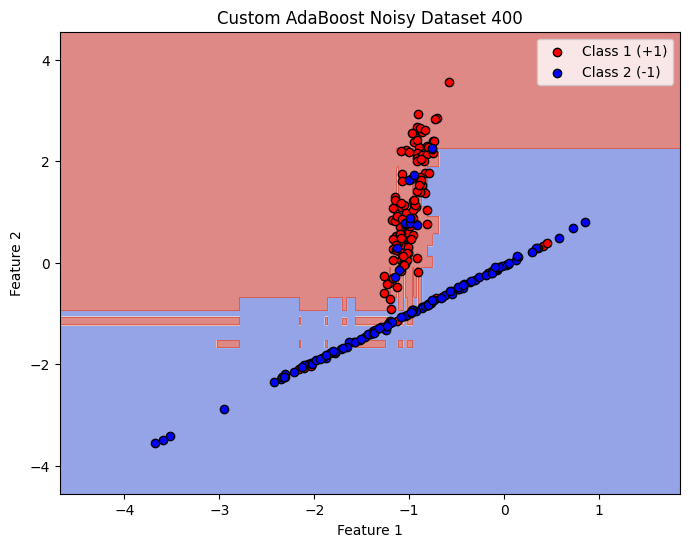

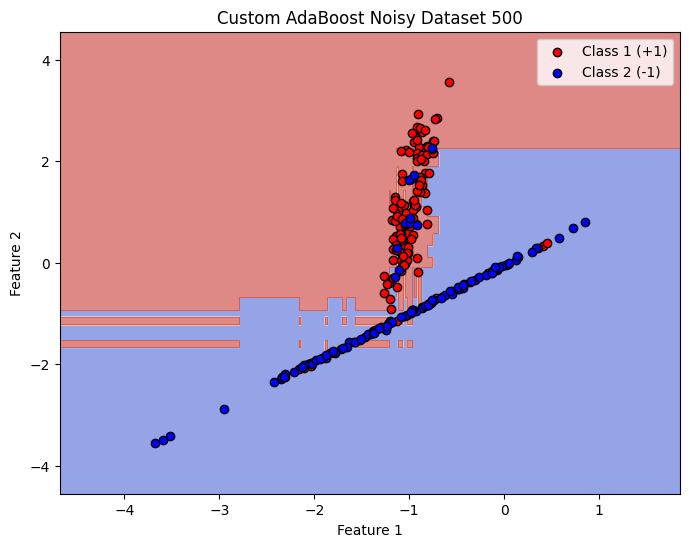

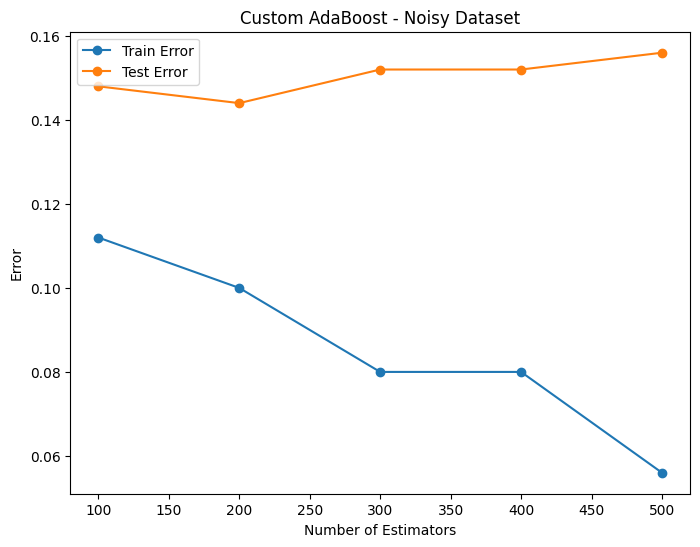

Train and Test Error Analysis on Dataset 2 (Separable)


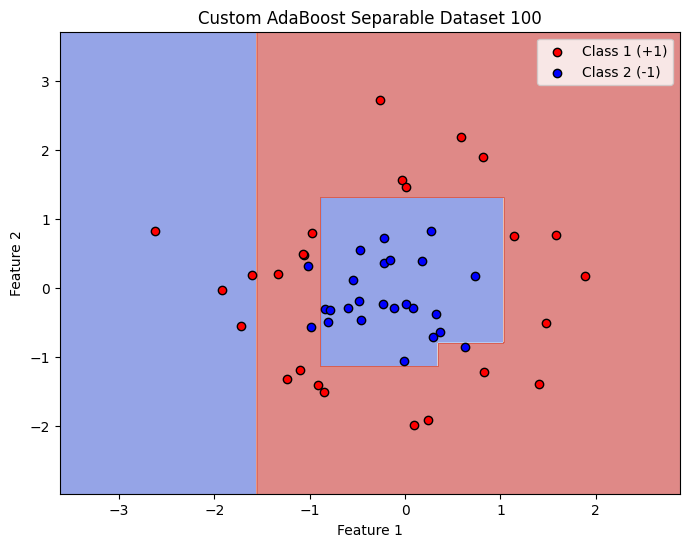

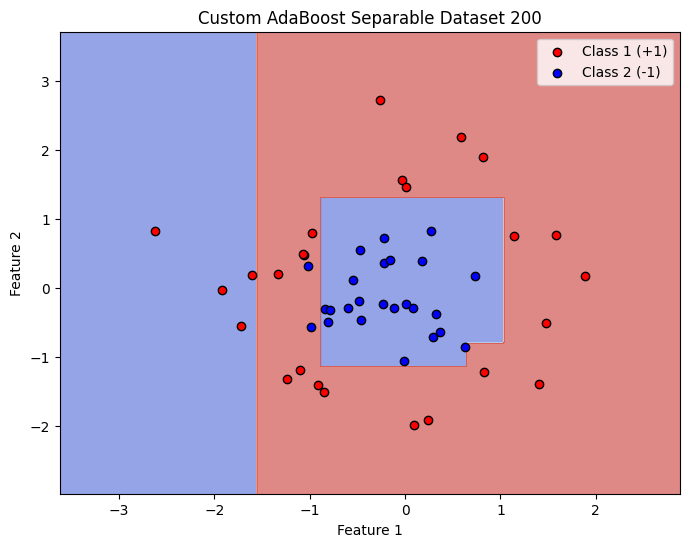

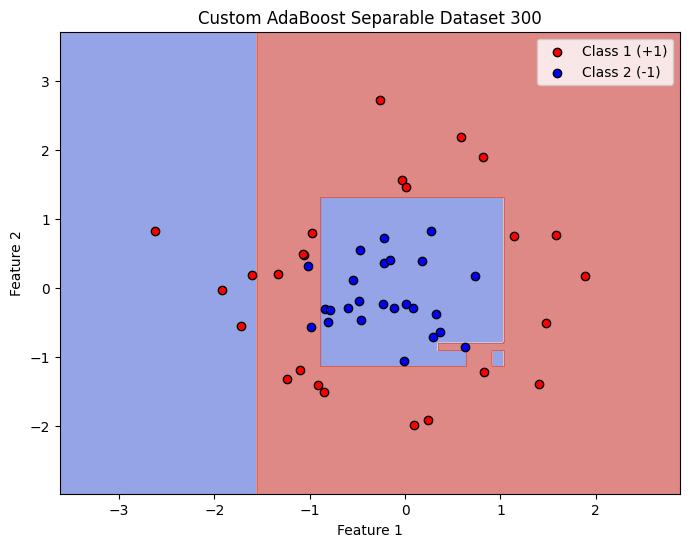

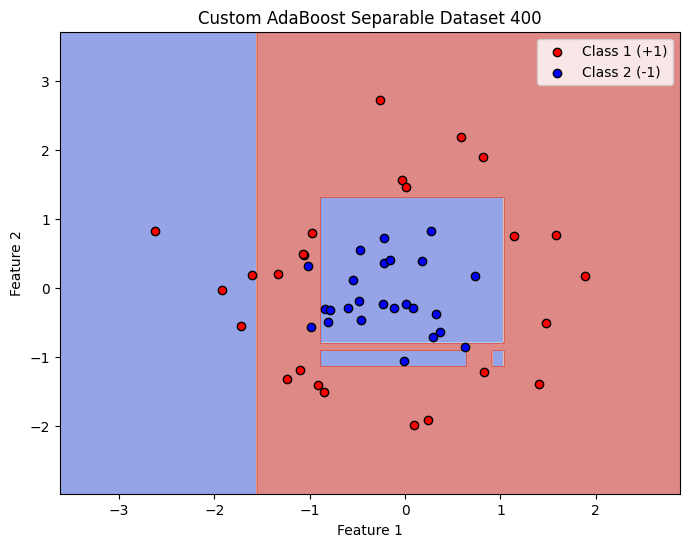

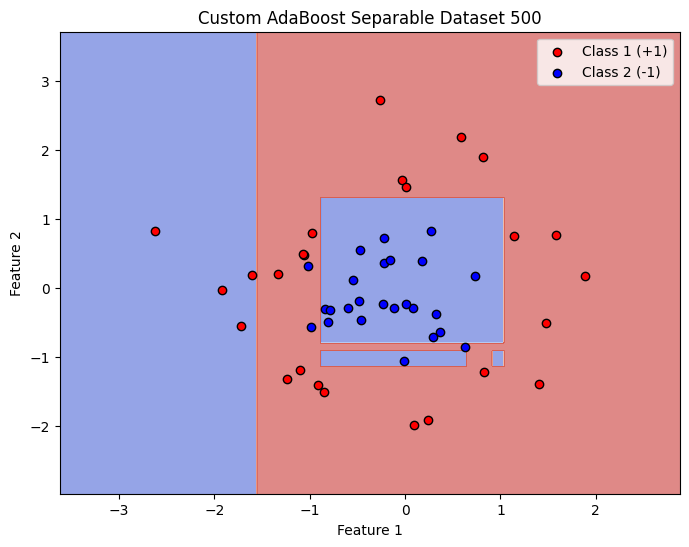

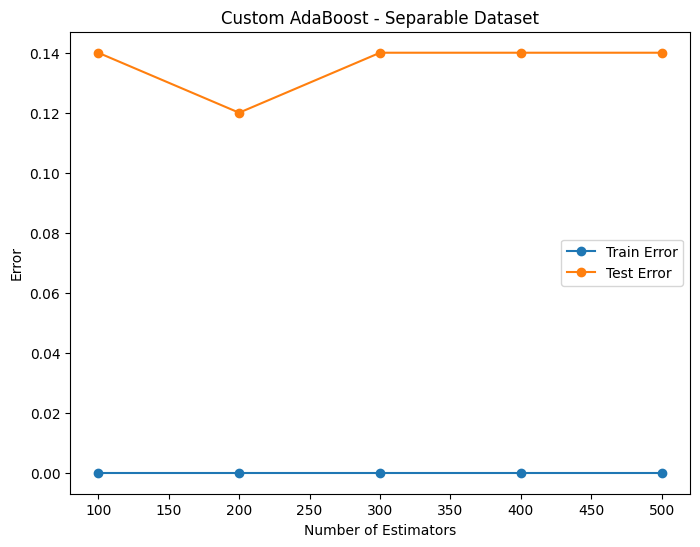

In [ ]:
# Hyperparameter range
param_range = {'n_estimators': [100, 200, 300, 400, 500]}

# Dataset 1: Noisy Data
print("Train and Test Error Analysis on Dataset 1 (Noisy)")
plot_train_test_error(AdaBoostCustom, param_range, X1_train, y1_train, X1_test, y1_test, "Custom AdaBoost", "Noisy Dataset")

# Dataset 2: Small and Separable Data
print("Train and Test Error Analysis on Dataset 2 (Separable)")
plot_train_test_error(AdaBoostCustom, param_range, X2_train, y2_train, X2_test, y2_test, "Custom AdaBoost", "Separable Dataset")


For both 200 estimatiors will avoid over fitting

In [ ]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score
from sklearn.model_selection import GridSearchCV

# Function to evaluate models
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else None,
        "Precision": precision_score(y_test, y_pred)
    }

    print(f"{model_name} Results:")
    for metric, value in metrics.items():
        if value is not None:
            print(f"{metric}: {value:.2f}")
    return metrics

# Hyperparameter tuning for each model
# Sklearn AdaBoost
ada_params = {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0]}
ada_model = GridSearchCV(AdaBoostClassifier(random_state=42), ada_params, scoring="accuracy")

# Gradient Boosting
gb_params = {"n_estimators": [50, 100, 200], "learning_rate": [0.1, 0.5, 1.0], "max_depth": [1, 3, 5]}
gb_model = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, scoring="accuracy")

# Random Forest
rf_params = {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 10]}
rf_model = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, scoring="accuracy")

# Custom AdaBoost - fix n_estimators and learning rate manually
custom_model = AdaBoostCustom(n_estimators=100)

# Models dictionary
models = {
    "Custom AdaBoost": custom_model,
    "Sklearn AdaBoost": ada_model,
    "Gradient Boosting": gb_model,
    "Random Forest": rf_model
}


Evaluating models on Dataset 1 (Noisy):

Custom AdaBoost Results:
Accuracy: 0.85
F1-Score: 0.85
Precision: 0.92


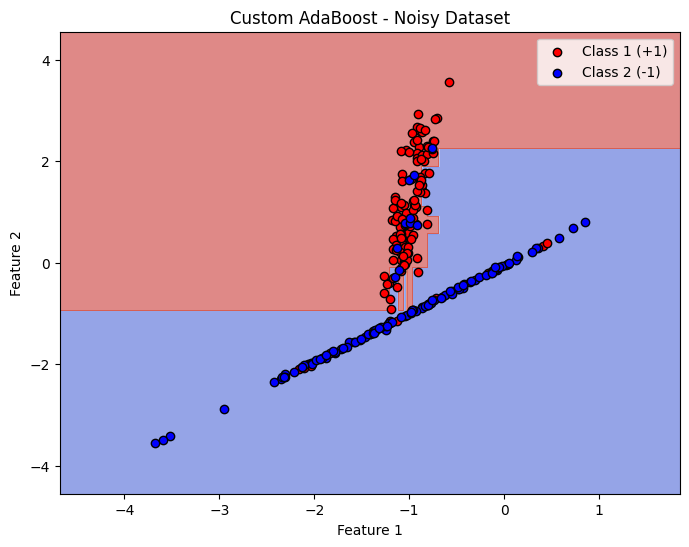

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

Sklearn AdaBoost Results:
Accuracy: 0.87
F1-Score: 0.88
ROC-AUC: 0.88
Precision: 0.92


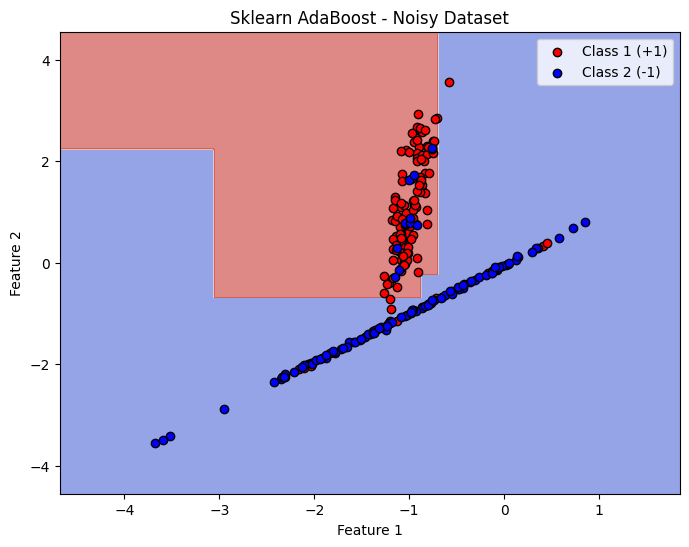

Gradient Boosting Results:
Accuracy: 0.87
F1-Score: 0.88
ROC-AUC: 0.88
Precision: 0.92


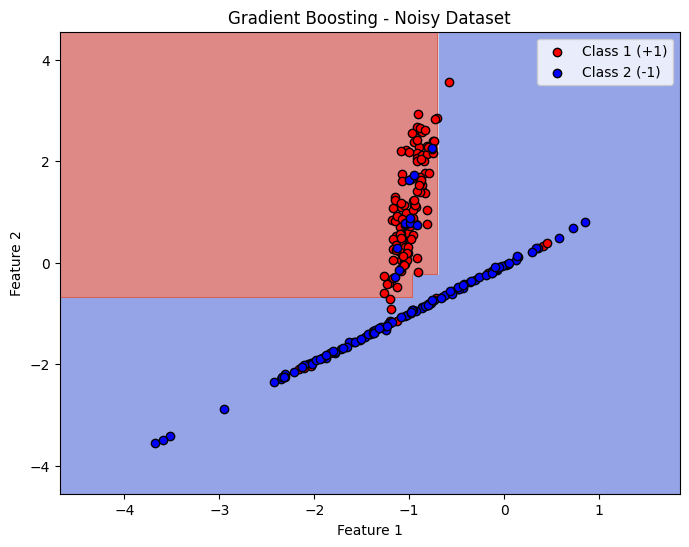

Random Forest Results:
Accuracy: 0.86
F1-Score: 0.87
ROC-AUC: 0.87
Precision: 0.92


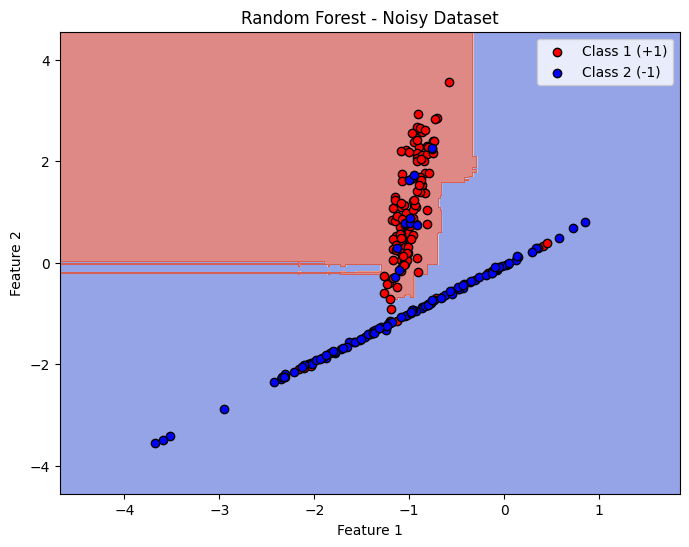

Evaluating models on Dataset 2 (Separable):

Custom AdaBoost Results:
Accuracy: 0.82
F1-Score: 0.80
Precision: 0.90


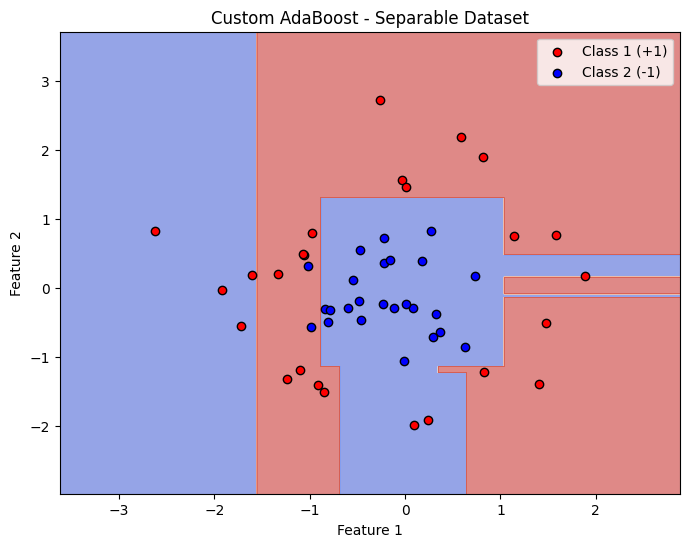

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

Sklearn AdaBoost Results:
Accuracy: 0.94
F1-Score: 0.94
ROC-AUC: 0.97
Precision: 0.89


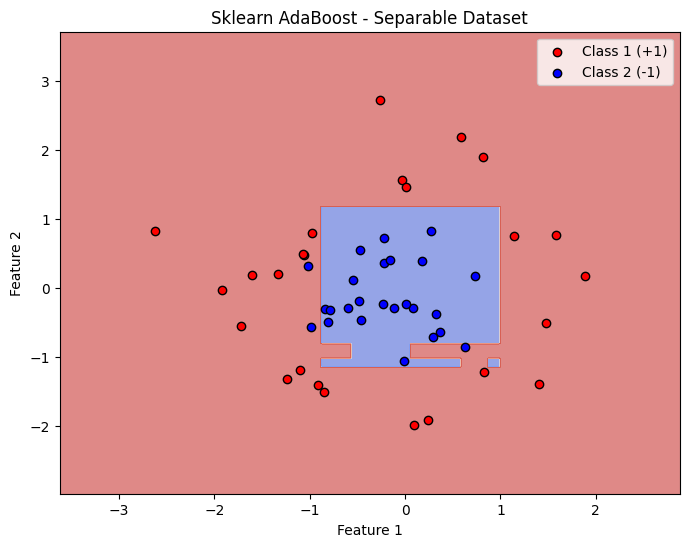

Gradient Boosting Results:
Accuracy: 0.96
F1-Score: 0.96
ROC-AUC: 0.96
Precision: 0.96


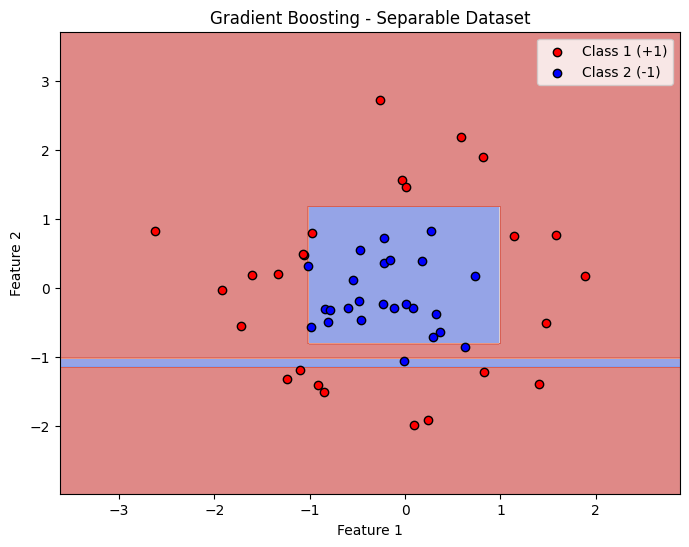

Random Forest Results:
Accuracy: 0.92
F1-Score: 0.93
ROC-AUC: 0.96
Precision: 0.86


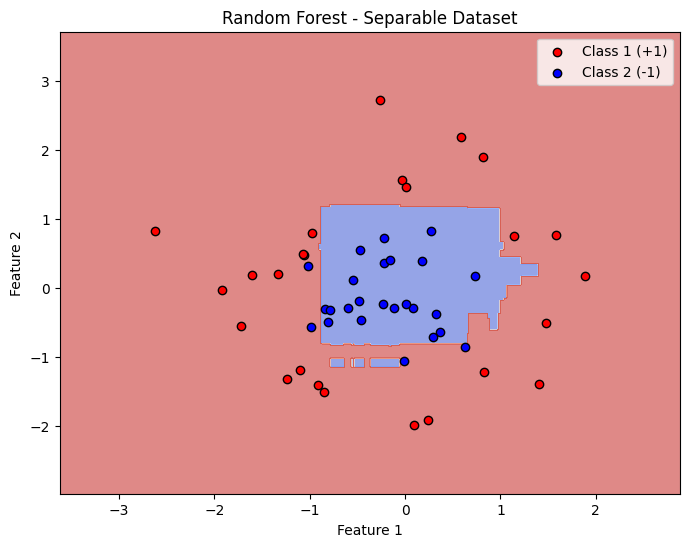

In [ ]:
print("Evaluating models on Dataset 1 (Noisy):\n")
results_noisy = {}
for model_name, model in models.items():
    if "Custom" in model_name:  # Custom model doesn't need GridSearch
        model.fit(X1_train, y1_train)
        metrics = evaluate_model(model, X1_train, y1_train, X1_test, y1_test, model_name)
        plot_decision_boundaries(X1_test, y1_test, model, title=f"{model_name} - Noisy Dataset")
    else:
        model.fit(X1_train, y1_train)
        best_model = model.best_estimator_
        metrics = evaluate_model(best_model, X1_train, y1_train, X1_test, y1_test, model_name)
        plot_decision_boundaries(X1_test, y1_test, best_model, title=f"{model_name} - Noisy Dataset")
    results_noisy[model_name] = metrics

# Dataset 2 (Separable)
print("Evaluating models on Dataset 2 (Separable):\n")
results_separable = {}
for model_name, model in models.items():
    if "Custom" in model_name:
        model.fit(X2_train, y2_train)
        metrics = evaluate_model(model, X2_train, y2_train, X2_test, y2_test, model_name)
        plot_decision_boundaries(X2_test, y2_test, model, title=f"{model_name} - Separable Dataset")
    else:
        model.fit(X2_train, y2_train)
        best_model = model.best_estimator_
        metrics = evaluate_model(best_model, X2_train, y2_train, X2_test, y2_test, model_name)
        plot_decision_boundaries(X2_test, y2_test, best_model, title=f"{model_name} - Separable Dataset")
    results_separable[model_name] = metrics


Evaluation Metrics:

- Accuracy: Measures overall correctness.
- F1-score: Balances precision and recall, especially useful for noisy data.
- ROC-AUC: Measures the ability to distinguish between classes.
- Precision: Useful for understanding false positives on imbalanced/noisy datasets.

Metrics Comparison for Dataset 1 (Noisy):


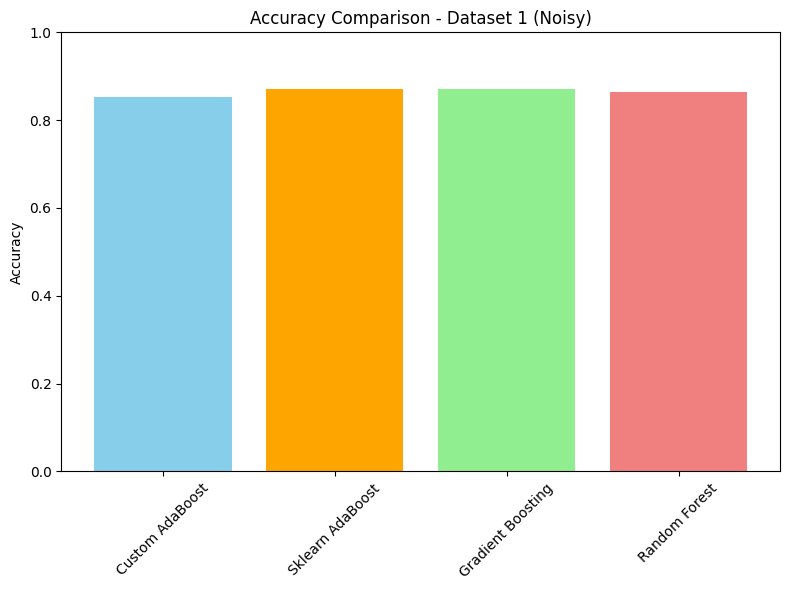

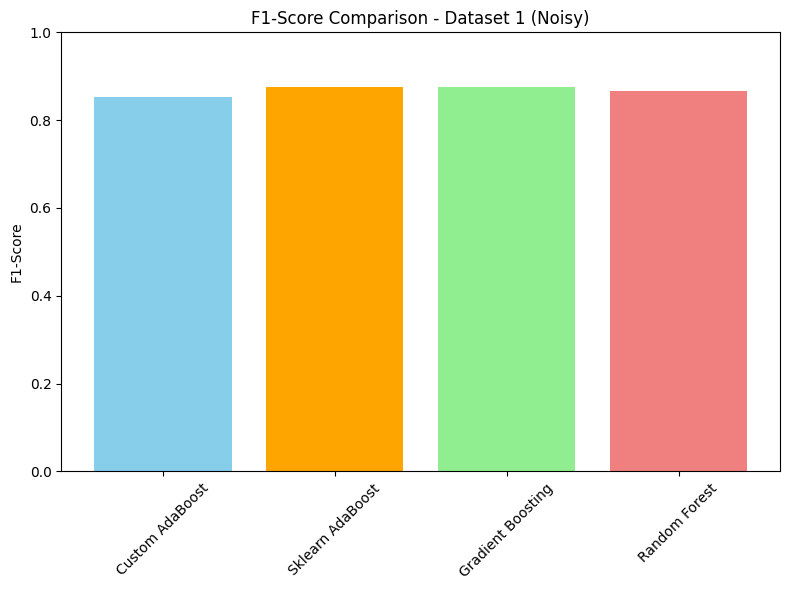

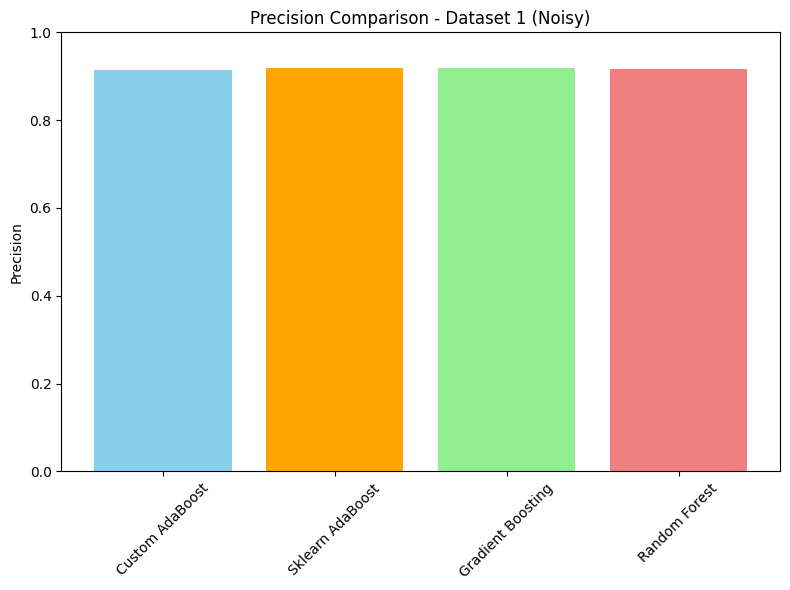

Metrics Comparison for Dataset 2 (Separable):


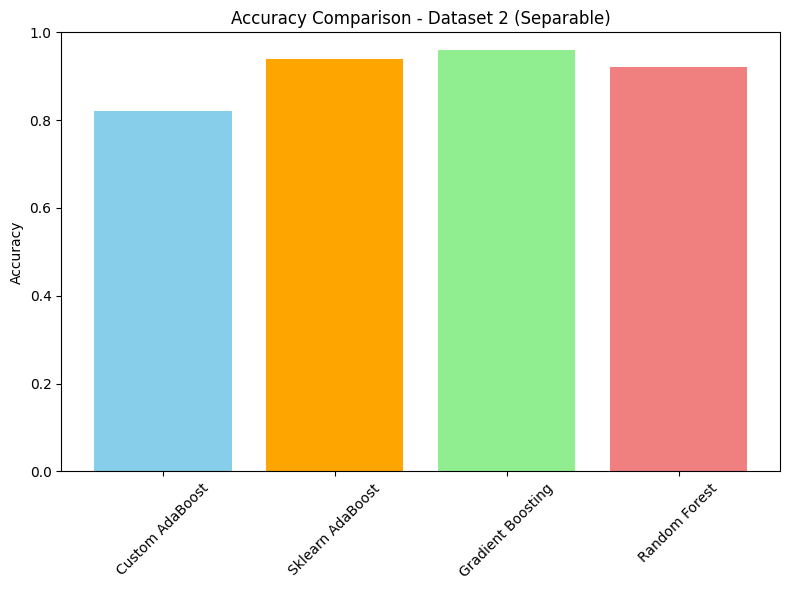

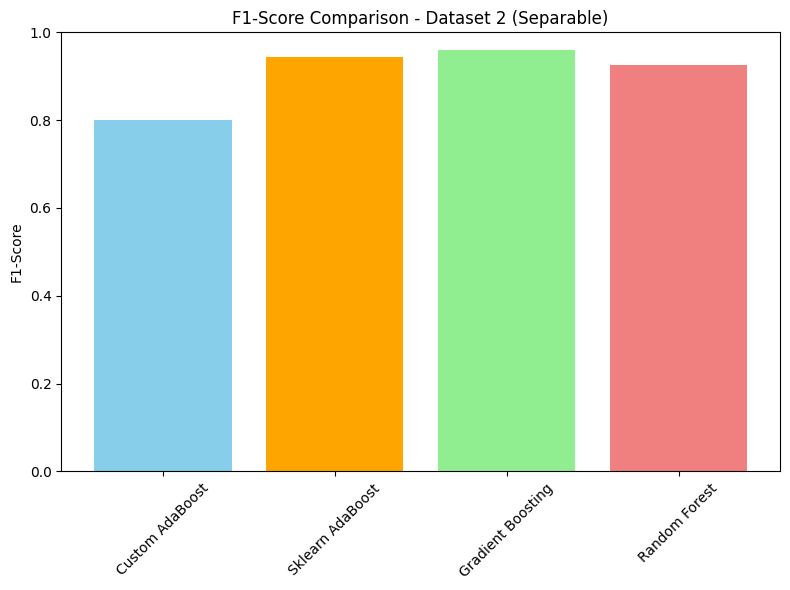

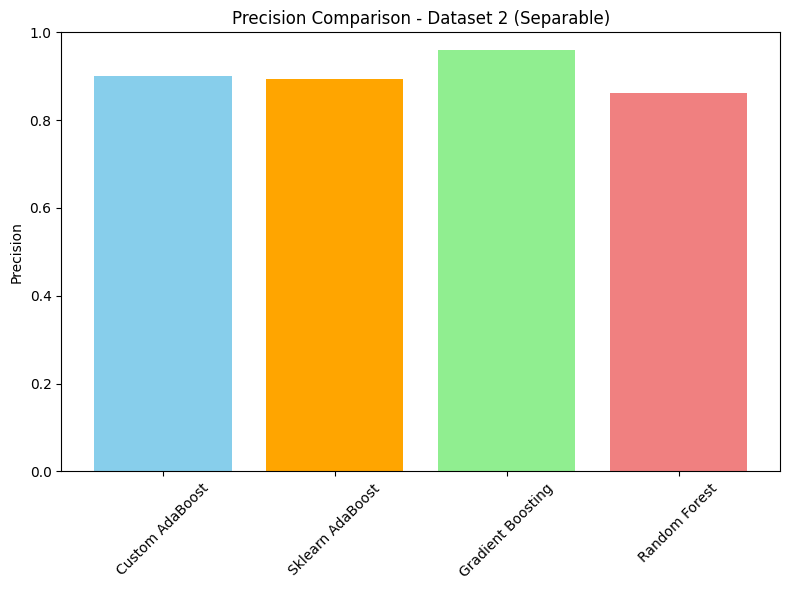

In [ ]:
import matplotlib.pyplot as plt

# Function to plot metrics comparison
def plot_metrics_comparison(results, dataset_name):
    metrics = ["Accuracy", "F1-Score", "Precision"]
    models = results.keys()

    # Extract metrics for all models
    for metric in metrics:
        values = [results[model][metric] for model in models]

        # Plot the graph
        plt.figure(figsize=(8, 6))
        plt.bar(models, values, color=['skyblue', 'orange', 'lightgreen', 'lightcoral'])
        plt.title(f"{metric} Comparison - {dataset_name}")
        plt.ylabel(metric)
        plt.xticks(rotation=45)
        plt.ylim(0, 1)  # All metrics are between 0 and 1
        plt.tight_layout()
        plt.show()

# Plot metrics for Dataset 1 (Noisy)
print("Metrics Comparison for Dataset 1 (Noisy):")
plot_metrics_comparison(results_noisy, "Dataset 1 (Noisy)")

# Plot metrics for Dataset 2 (Separable)
print("Metrics Comparison for Dataset 2 (Separable):")
plot_metrics_comparison(results_separable, "Dataset 2 (Separable)")


We will choose the models according to the appearance of the boundaries graphs, which alligns with the metric. we will choose the models that describe best the data but does not over fit.


**Dataset 1 (Noisy Data)**

In the noisy dataset, Custom AdaBoost achieved an accuracy of 85% with a precision of 92%. Its decision boundary reveals overfitting, as the model creates sharp and irregular regions to accommodate noisy points. This aligns with AdaBoost's known sensitivity to misclassified samples: it places higher weights on these points, leading to complexity in noisy data.

Random Forest performed slightly better, achieving 86% accuracy. Its decision boundary is smoother, reflecting its ability to generalize by averaging multiple decision trees. Random Forest is less affected by noise due to its bagging approach, which reduces variance and avoids overfitting to individual misclassified samples.

Conclusion: Random Forest handles noise more effectively than AdaBoost by maintaining smoother and more generalizable decision boundaries.

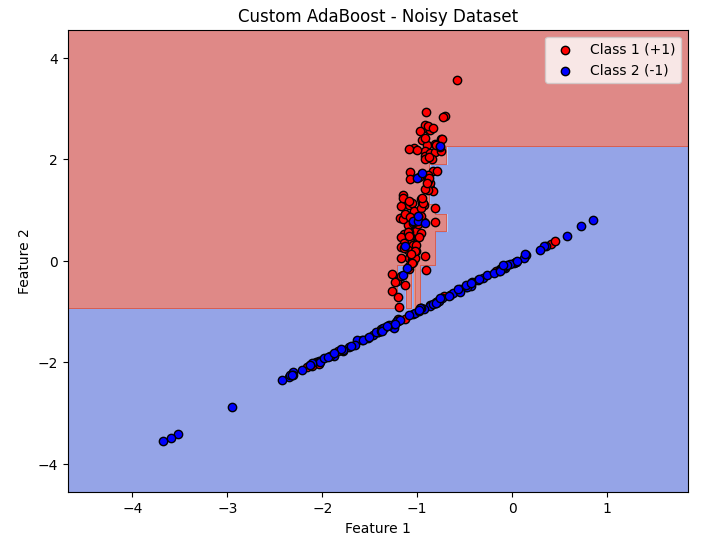

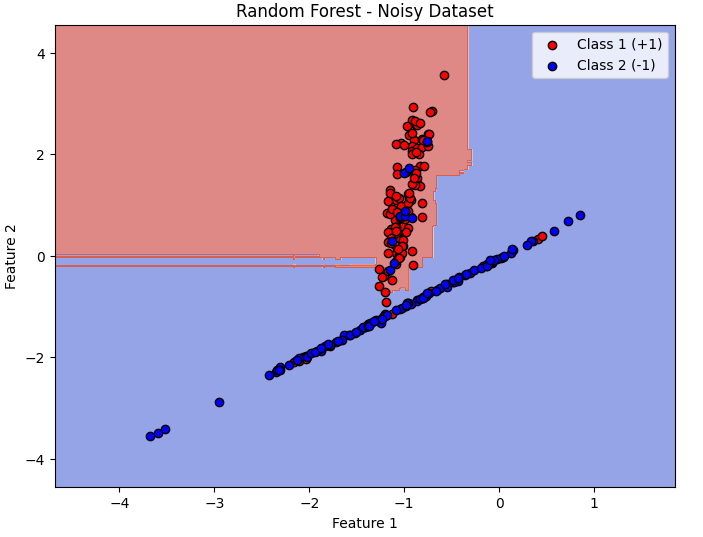

**Dataset 2 (Separable Data)**
On the small, perfectly separable dataset, Custom AdaBoost achieved an accuracy of 82% with a precision of 90% but displayed significant overfitting. The decision boundary shows sharp and irregular divisions, highlighting AdaBoost's tendency to focus excessively on individual points.

In contrast, Sklearn AdaBoost performed significantly better, with an accuracy of 94%, producing smoother and more generalizable boundaries due to its optimized implementation. Gradient Boosting outperformed all models with an accuracy of 96%, as it progressively minimizes errors and avoids overfitting better than AdaBoost. Random Forest also performed well with 92% accuracy, but its boundaries were less refined compared to Gradient Boosting.

Conclusion: Gradient Boosting provided the best generalization and accuracy by balancing flexibility and error minimization, while Custom AdaBoost overfitted to the small dataset.



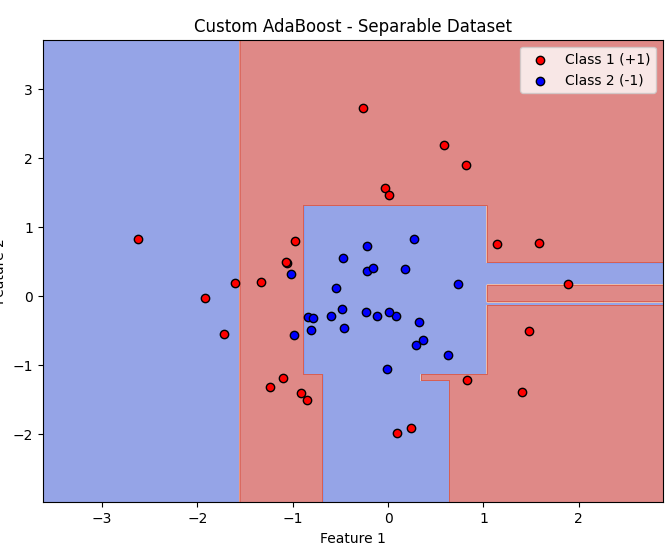

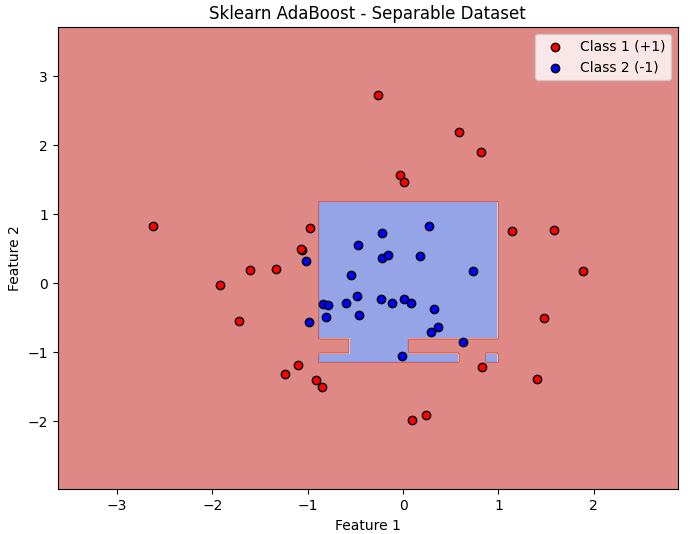

# Use of generative AI
We used generative AI to assist with rephrasing explanations and clarifying the concepts we wanted to present in a more concise and formal manner. Additionally, generative AI was leveraged to quickly provide implementations for syntactically complex tasks, such as generating and visualizing graphs, decision boundaries, and automating comparisons between models and hyperparameters. This allowed us to focus on analyzing results and interpreting model behavior effectively.